In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname("__file__"), '..')))

import random
import torch
import torch.nn as nn
import pandas as pd
from typing import Dict
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from AIPTBDose import AIPTBDoseGaussian, AIPTBDoseDotProduct, AttentionDataset, AIPTBDose, create_attention_datasets

In [3]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from typing import Dict, Any, Optional
from pathlib import Path
from sklearn.metrics import roc_curve, auc

from AIPTBDose import AttentionDataset, AIPTBDose

def save_results(
    model: AIPTBDose,
    datasets: Dict[str, AttentionDataset],
    train_history: Dict[str, list],
    best_states: Dict[str, Optional[dict]],
    save_dir: str = "results",
    experiment_name: str = "AIPTB_experiment",
    batch_size: int = 10
) -> None:
    #save_dir_full = Path(__file__).parent.parent / save_dir / experiment_name
    #save_dir_full.mkdir(parents=True, exist_ok=True)

    data = []
    for split, logs in train_history.items():
        for log in logs:
            row = {"split": split, "epoch": log["epoch"]}
            for k, v in log.items():
                if k != "epoch":
                    row[k] = v
            data.append(row)

    df = pd.DataFrame(data)
    #csv_history_path = save_dir_full / f"history.csv"
    #df.to_csv(csv_history_path, index=False, encoding="utf-8", sep=";", decimal=",")

    #best_data = []
    for split in [s for s in train_history]:
        if split not in train_history:
            continue
        logs = train_history[split]
        # Ищем эпоху с минимальным Loss (стандартный критерий)
        best_idx = min(range(len(logs)), key=lambda i: logs[i]["Loss"])
        best_log = logs[best_idx]

        row = {
            "split": split,
            "best_epoch": best_log["epoch"],
            "best_loss": best_log["Loss"],
        }
        for k, v in best_log.items():
            if k not in ["epoch", "Loss"]:
                row[f"best_{k}"] = v
        #best_data.append(row)

    #best_df = pd.DataFrame(best_data)
    #csv_best_path = save_dir_full / f"best_metrics.csv"
    #best_df.to_csv(csv_best_path, index=False, encoding="utf-8", sep=";", decimal=",")

    #for val_name in ["val1", "val2"]:
    #    if val_name in best_states and best_states[val_name] is not None:
    #        pth_path = save_dir_full / f"best_{val_name}.pth"
    #        torch.save(best_states[val_name], pth_path)


    metrics = [col for col in df.columns if col not in ["split", "epoch"]]

    split_styles = {
        "train": {"color": "black", "linestyle": "--", "label": "Train"},
        "val1":  {"color": "blue",  "linestyle": "-.", "label": "Val 1"},
        "val2":  {"color": "red",   "linestyle": "-", "label": "Val 2"},
    }

    for metric in metrics:
        fig, ax = plt.subplots(figsize=(7, 5))

        for split in train_history.keys():
            split_df = df[df["split"] == split].sort_values("epoch")
            if not split_df.empty:
                style = split_styles.get(
                    split,
                    {"color": "gray", "linestyle": "-", "label": split}  # fallback
                )
                ax.plot(
                    split_df["epoch"],
                    split_df[metric],
                    color=style["color"],
                    linestyle=style["linestyle"],
                    linewidth=1.5,
                    label=style["label"]
                )

        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric.capitalize())
        #ax.set_title(f'{metric}')
        ax.legend(fontsize=12)
        ax.grid(True, linestyle=":", alpha=0.7)

        #png_path = save_dir_full / f"{metric}.png"
        plt.show()

    fig, ax = plt.subplots(figsize=(7, 5))

    model.eval()
    roc_data = []

    for split_name in ["train", "val1", "val2"]:
        if split_name not in datasets:
            continue

        if split_name in best_states and best_states[split_name] is not None:
            model.load_state_dict(best_states[split_name])

        style = split_styles[split_name]
        y_true = []
        y_score = []

        with torch.no_grad():
            ds = datasets[split_name]
            indices_all = torch.arange(ds["feature"].shape[0])
            mask_self_attention = split_name=="train"

            for i in range(0, len(indices_all), batch_size):
                limiter = i + batch_size
                if limiter >= len(indices_all):
                    limiter = len(indices_all)  # - 1
                indices = indices_all[i:limiter]
                query = ds["feature"][indices, :]
                values_q = ds["value"][indices, :]
                idx_key = None
                idx_query = None

                if mask_self_attention:
                    mask = torch.ones(len(indices_all), dtype=torch.bool)
                    mask[i:limiter] = False
                    idx_key = indices_all[mask]
                    idx_query = indices

                output = model(
                    query=query,
                    query_indicies=idx_query,
                    mask_self_attention=mask_self_attention
                ).squeeze(0)

                y_true.append(values_q.cpu().numpy().flatten())
                y_score.append(output.cpu().numpy().flatten())

        y_true = np.concatenate(y_true)
        y_score = np.concatenate(y_score)# > 0.5) * 1.0

        #df = pd.DataFrame(np.column_stack((y_true, y_score)), columns=['y_true', 'y_score'])
        #df.to_csv(save_dir_full / f"prediction_{split_name}.csv", index=True, sep=";", decimal=",")

        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)

        ax.plot(fpr, tpr,
                color=style["color"],
                linestyle=style["linestyle"],
                linewidth=1.5,
                label=f'{style["label"]} (AUC = {roc_auc:.4f})')
        #roc_data.append({"split": f"{split_name}", "fpr": fpr, "tpr": tpr})

    #roc_df = pd.DataFrame(roc_data)
    #roc_df.to_csv(save_dir_full / "roc_curves_data.csv", index=False, sep=";", decimal=",")

    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.5)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC curves')
    ax.legend(loc="lower right", fontsize=12)
    ax.grid(True, linestyle=":")
    plt.show()


In [4]:
import numpy as np
import pandas as pd

from abc import ABC, abstractmethod

class DataGenerator:
    def __init__(self, dim:int, A_bounds: list[int]):
        self.dim = dim
        self.A_bounds = A_bounds
        self.features = []
        for i in range(1, self.dim + 1):
            self.features.append(f'x{i}')
        self.labels = self.features + ["a", "y", "c"]

    @abstractmethod
    def generate_coeffs(self, A, randoms):
        pass

    @abstractmethod
    def generate_randoms(self, N: int):
        pass

    @abstractmethod
    def generate_X(self, N: int, coeffs=None):
        pass

    @abstractmethod
    def generate_A(self, N: int, low: int, up: int):
        pass

    @abstractmethod
    def generate_y(self, X, A, censor_rate:float, coeffs=None):
        pass

    def generate(self, controls: int, treats: int, censor_rate: float, generate_test: bool):
        A_c = self.generate_A(controls, 0, 0)
        R_c = self.generate_randoms(controls)
        Coeffs_c = self.generate_coeffs(A_c, R_c)
        X_c = self.generate_X(controls, Coeffs_c)
        Y_c, C_c = self.generate_y(X_c, A_c, censor_rate, Coeffs_c)

        A_t = self.generate_A(treats, self.A_bounds[0], self.A_bounds[1])
        R_t = self.generate_randoms(treats)
        Coeffs_t = self.generate_coeffs(A_t, R_t)
        X_t = self.generate_X(treats, Coeffs_t)
        Y_t, C_t = self.generate_y(X_t, A_t, censor_rate, Coeffs_t)

        df_c = pd.DataFrame(
            np.column_stack((X_c, A_c, Y_c, C_c)),
            columns=self.labels,
        )
        df_t = pd.DataFrame(
            np.column_stack((X_t, A_t, Y_t, C_t)),
            columns=self.labels,
        )

        df = pd.concat([df_c, df_t], ignore_index=True)

        if generate_test:
            T_test = None
            if not Coeffs_c is None:
                if not Coeffs_t is None:
                    A_t_c = self.generate_A(treats, 0, 0)
                    Coeffs_t_c = self.generate_coeffs(A_t_c, R_t)
                    T_test = np.concat([Coeffs_c, Coeffs_t_c], axis=0)

            mask_control = range(0, controls)

            X_test = df[self.features].values
            A_test = self.generate_A(X_test.shape[0], 0, 0)
            A_test[mask_control] = self.generate_A(X_c.shape[0], self.A_bounds[0], self.A_bounds[1])
            Y_test, _ = self.generate_y(X_test, A_test, 0, T_test)
            C_test = df['c'].values

            labels_test = [l + "_test" for l in self.labels]

            df_test = pd.DataFrame(
                np.column_stack((X_test, A_test, Y_test, C_test)),
                columns=labels_test,
                index=df.index
            )
            df = pd.merge(df, df_test, left_index=True, right_index=True)
            te_test = np.where(df['a'] == 0, df['y_test'] - df['y'] > 0,  df['y'] - df['y_test'] > 0)
            df['te_test'] = te_test
        return df

In [5]:
L2_reg = 1e-4
learning_rate = 5e-2
experiment_name = "AIPTB_test"
random_seed = 42
epochs = 100
batch_size = 500000
min_A_weight = 0.3

In [6]:
def fit_model(df: pd.DataFrame, dim: int, model: AIPTBDose, is_debug=False):
    y = df['a'].values
    X = df.drop(columns='a').values
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
    fold_number = 0
    
    for train_idx, val_idx in skf.split(X, y):
        datasets, scaler = create_attention_datasets(
            df=df,
            train_idx=train_idx,
            val_idx=val_idx,
            dim=dim
        )

        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=L2_reg)
        loss_fn = nn.BCELoss()

        train_history, best_states = model.fit(
            datasets=datasets,
            optimizer=optimizer,
            loss_fn=loss_fn,
            num_epochs=epochs,
            batch_size = batch_size,
            metric_fns={
                #"F1": f1_score,
                #"Accuracy": accuracy_score,
                "Precision": precision_score,
                "Recall": recall_score
            }
            
        )

        save_results(
            model=model,
            datasets=datasets,
            train_history=train_history,
            best_states=best_states,
            save_dir="Output",
            experiment_name=f"{experiment_name}/Folds/{fold_number}",
            batch_size=batch_size,
        )
        
        break # run only one fold 
        fold_number += 1

# Example (Simple dataset)

In [7]:
class DataGeneratorSimple(DataGenerator):
    def __init__(self, dim: int, A_bounds: list[int]):
        super().__init__(dim, A_bounds)

    def generate_coeffs(self, A, randoms):
        return None

    def generate_randoms(self, N: int):
        return None

    def generate_X(self, N: int, coeffs=None):
        return np.random.uniform(0, 1, (N, self.dim))

    def generate_A(self, N: int, low: int, up: int):
        return np.random.randint(low, up+1, (N))

    def generate_y(self, X, A,  censor_rate:float, coeffs=None):
        N = X.shape[0]
        Y = (1 - 0.25 * A) * X[:, 0] + (0.25 + 0.25 * A) * X[:, 1]
        C = np.random.uniform(0, 1, (N)) >= censor_rate

        return Y, C

In [8]:
datagen = DataGeneratorSimple(2, [1,3])
df_simple = datagen.generate(controls=50, treats=50, censor_rate=0.0, generate_test=True)
print(df_simple.head())

         x1        x2    a         y    c   x1_test   x2_test  a_test  \
0  0.685860  0.760815  0.0  0.876064  1.0  0.685860  0.760815     2.0   
1  0.199067  0.408014  0.0  0.301070  1.0  0.199067  0.408014     2.0   
2  0.564723  0.890898  0.0  0.787447  1.0  0.564723  0.890898     1.0   
3  0.993199  0.392920  0.0  1.091429  1.0  0.993199  0.392920     2.0   
4  0.834557  0.927828  0.0  1.066514  1.0  0.834557  0.927828     3.0   

     y_test  c_test  te_test  
0  0.913541     1.0     True  
1  0.405544     1.0     True  
2  0.868991     1.0     True  
3  0.791290     1.0    False  
4  1.136467     1.0     True  


## AIPTB_Dose_Gaussian

Epoch 1/100
New best result for train (Loss = 0.227642)
New best result for val1 (Loss = 0.239551)
New best result for val2 (Loss = 0.353293)
Epoch 2/100
New best result for train (Loss = 0.216168)
New best result for val1 (Loss = 0.230873)
New best result for val2 (Loss = 0.340916)
Epoch 3/100
New best result for train (Loss = 0.204779)
New best result for val1 (Loss = 0.223042)
New best result for val2 (Loss = 0.328990)
Epoch 4/100
New best result for train (Loss = 0.193455)
New best result for val1 (Loss = 0.216328)
New best result for val2 (Loss = 0.317988)
Epoch 5/100
New best result for train (Loss = 0.182198)
New best result for val1 (Loss = 0.211117)
New best result for val2 (Loss = 0.308633)
Epoch 6/100
New best result for train (Loss = 0.171043)
New best result for val1 (Loss = 0.207944)
New best result for val2 (Loss = 0.301991)
Epoch 7/100
New best result for train (Loss = 0.159987)
New best result for val1 (Loss = 0.207498)
New best result for val2 (Loss = 0.299541)
Epoch 

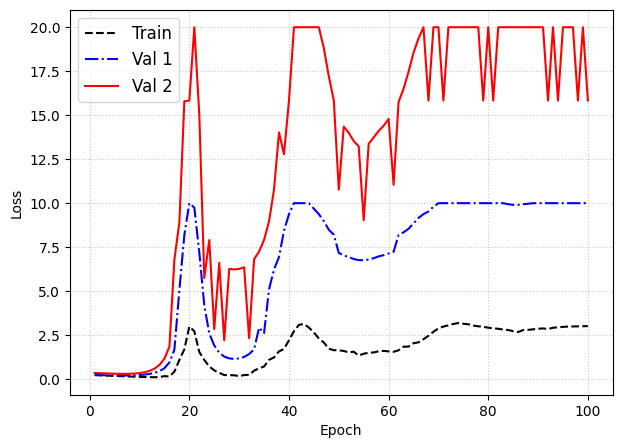

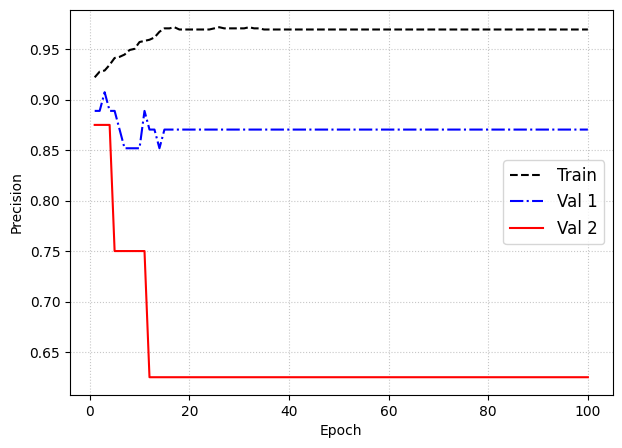

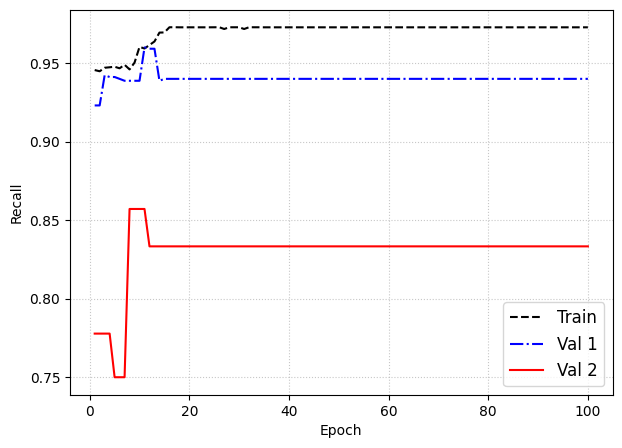

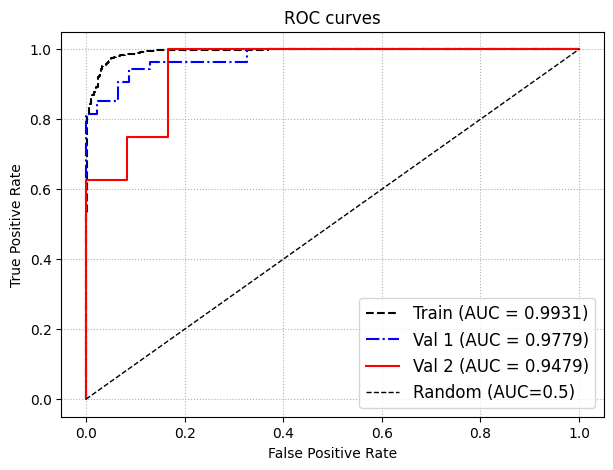

In [9]:
aiptb_gaussian = AIPTBDoseGaussian(initial_temperature=1.0, debug=True)
fit_model(df=df_simple.copy(), dim=2, model=aiptb_gaussian)

## AIPTB_Dose_DotProduct

Training: 100%|███████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:08<00:00, 12.26it/s, loss=train=0.1543 val1=0.3118 val2=0.1392]


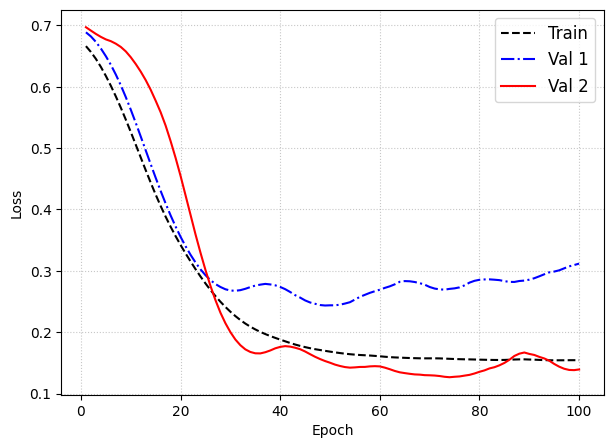

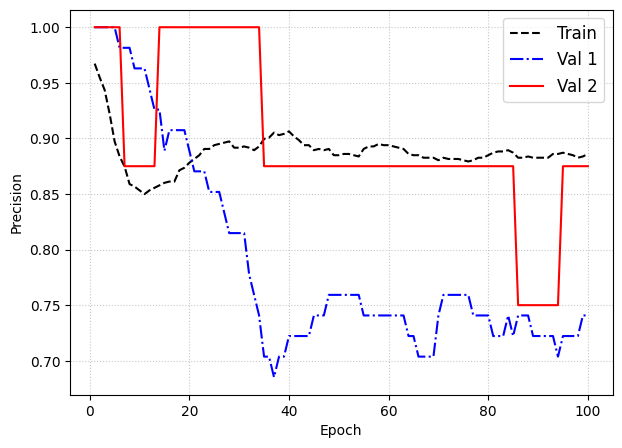

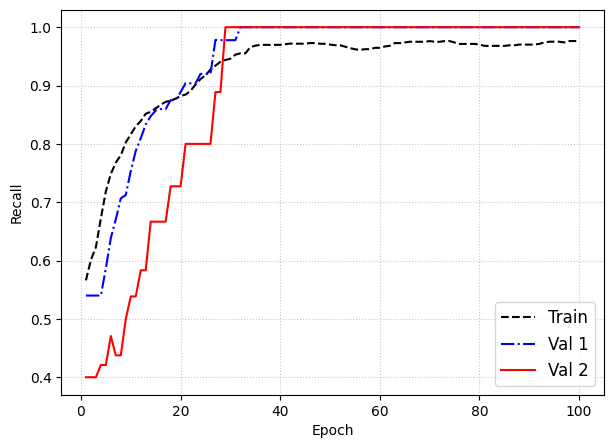

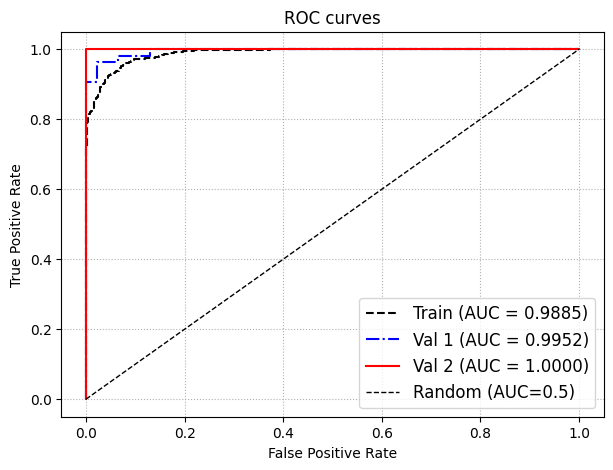

In [10]:
aiptb_dotproduct = AIPTBDoseDotProduct(dim=2, min_A_weight=min_A_weight)
fit_model(df=df_simple.copy(), dim=2, model=aiptb_dotproduct, is_debug=True)

# Example (Spiral dataset)

In [11]:
class DataGeneratorSpiral(DataGenerator):
    def __init__(self, dim: int, A_bounds: list[int], T_bounds: list[float]):
        super().__init__(dim, A_bounds)
        self.T_bounds = T_bounds

    def generate_coeffs(self, A, randoms):
        A_coeff = randoms[:,1] + A * 0.2
        B_coeff = - randoms[:,2] * A * 1.5
        T = randoms[:,0]

        return np.column_stack((T, A_coeff, B_coeff))

    def generate_randoms(self, N: int):
        A_coeff = np.random.uniform(0.6,1.0, N)#0.6, 1, N)
        B_coeff = np.random.uniform(0.6,1.0, N)#0.6, 1, N)
        T = np.random.uniform(self.T_bounds[0], self.T_bounds[1], N)

        return np.column_stack((T, A_coeff, B_coeff))

    def generate_X(self, N: int, coeffs=None):
        T = coeffs[:,0]

        N = T.shape[0]
        X = np.zeros((N, self.dim))

        for i in range(0, self.dim, 2):
            freq = 1 + i // 2
            X[:, i] = T * np.sin(T * freq)
            if i + 1 < self.dim:
                X[:, i + 1] = T * np.cos(T * freq)

        return X

    def generate_A(self, N: int, low: int, up: int):
        return np.random.randint(low, up+1, (N))

    def generate_y(self, X, A, censor_rate:float, coeffs=None):
        T = coeffs[:, 0]
        A_coeff = coeffs[:, 1]
        B_coeff = coeffs[:, 2]

        N = T.shape[0]

        Y = A_coeff * T + B_coeff
        C = np.random.uniform(0, 1, (N)) >= censor_rate

        return Y, C

In [12]:
datagen = DataGeneratorSpiral(3, [1,5], [1.0, 12.0])
df_spiral = datagen.generate(controls=50, treats=50, censor_rate=0.0, generate_test=True)
print(df_spiral.head())

          x1        x2        x3    a         y    c    x1_test   x2_test  \
0  -4.608149 -0.401079  0.799137  0.0  3.366802  1.0  -4.608149 -0.401079   
1   0.199710 -3.070146 -0.398578  0.0  1.964169  1.0   0.199710 -3.070146   
2  -1.797553 -3.183177  3.130453  0.0  2.606401  1.0  -1.797553 -3.183177   
3   2.290733 -8.881711 -4.436289  0.0  6.210480  1.0   2.290733 -8.881711   
4 -10.069266 -3.502000  6.615328  0.0  9.257689  1.0 -10.069266 -3.502000   

    x3_test  a_test    y_test  c_test  te_test  
0  0.799137     1.0  3.366802     1.0    False  
1 -0.398578     1.0  1.964169     1.0    False  
2  3.130453     1.0  2.606401     1.0    False  
3 -4.436289     1.0  6.210480     1.0    False  
4  6.615328     2.0  9.257689     1.0    False  


Training: 100%|███████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:09<00:00, 10.50it/s, loss=train=0.4057 val1=0.5638 val2=0.8333]


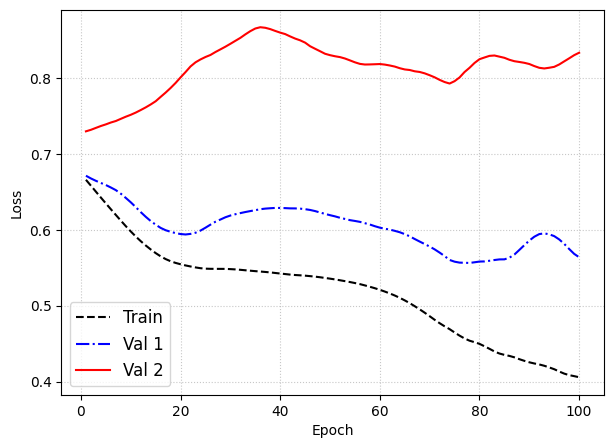

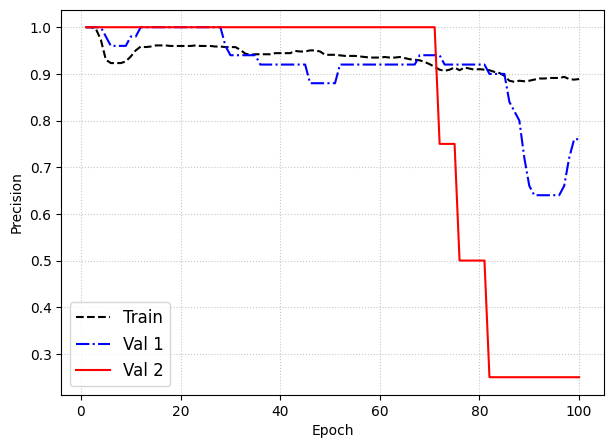

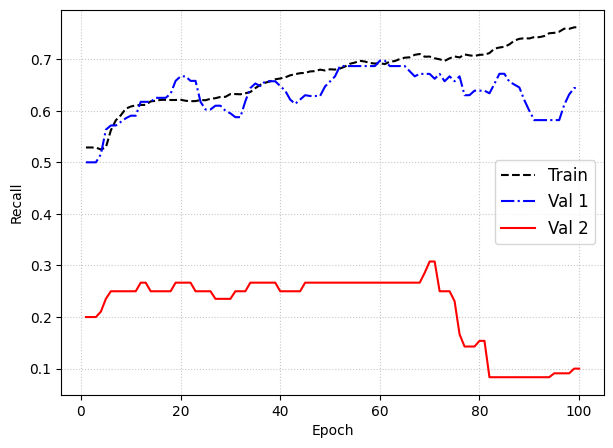

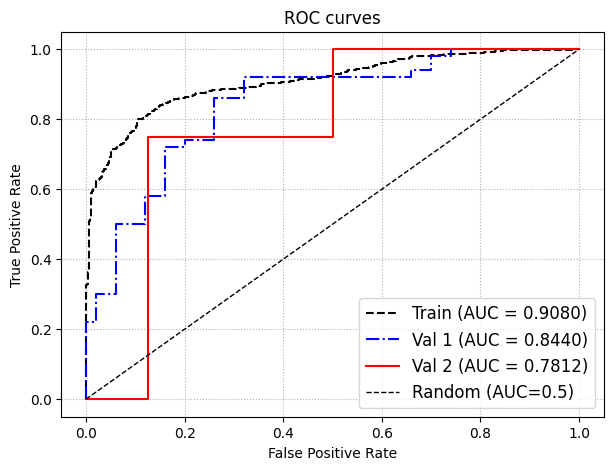

In [13]:
aiptb_dotproduct = AIPTBDoseDotProduct(dim=3, min_A_weight=min_A_weight)
fit_model(df=df_spiral.copy(), dim=3, model=aiptb_dotproduct)

# Example (Spiral dataset no test)

In [14]:
datagen = DataGeneratorSpiral(3, [1,5], [1.0, 12.0])
df_spiral = datagen.generate(controls=50, treats=50, censor_rate=0.0, generate_test=False)
print(df_spiral.head())

         x1        x2        x3    a         y    c
0  0.804273 -2.740559 -1.543454  0.0  2.131949  1.0
1  7.885884 -1.691750 -3.308229  0.0  6.469600  1.0
2  7.839231 -2.100600 -4.058037  0.0  5.996308  1.0
3  5.599384  4.491129  7.006866  0.0  7.119865  1.0
4  7.725622 -2.729401 -5.147030  0.0  6.508566  1.0


Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:08<00:00, 11.92it/s, loss=train=0.3551 val1=0.4043]


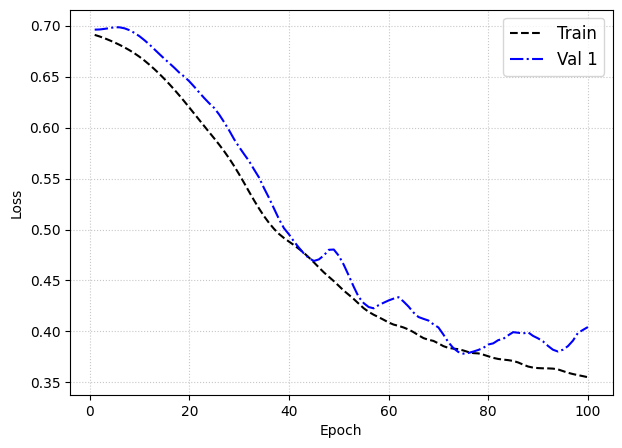

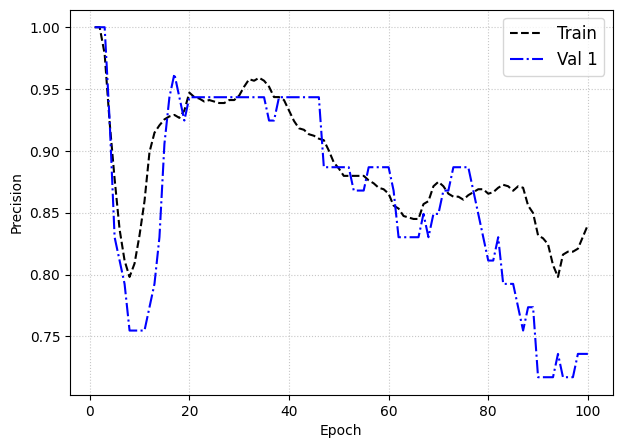

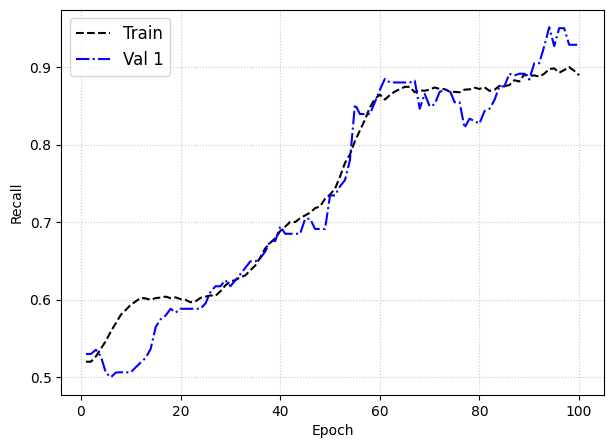

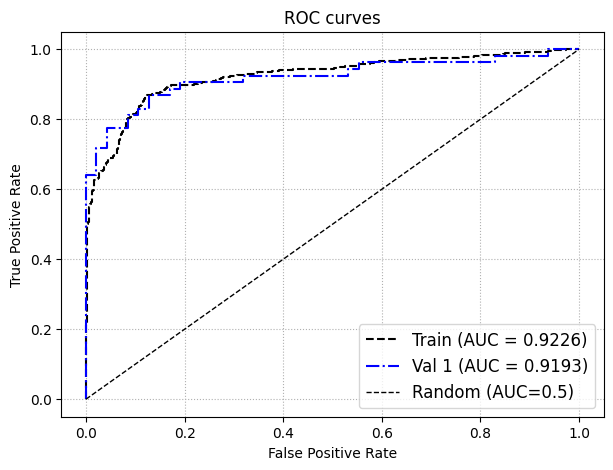

In [15]:
aiptb_dotproduct = AIPTBDoseDotProduct(dim=3, min_A_weight=min_A_weight)
fit_model(df=df_spiral.copy(), dim=3, model=aiptb_dotproduct)